In [ ]:
pip install opencv-python opencv-python-headless


In [ ]:
# Install OpenCV in Google Colab
!pip install opencv-python opencv-python-headless

# Download YOLOv3 weights, config file, and coco.names
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
!wget https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true -O coco.names


--2025-03-06 02:52:24--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  16.6MB/s    in 13s     

2025-03-06 02:52:37 (18.6 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2025-03-06 02:52:37--  https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/pjreddie/darknet/raw/refs/heads/master/cfg/yolov3.cfg [following]
--2025-03-06 02:52:37--  https://github.com/pjreddie/darknet/raw/refs/heads/master/cfg/yolov3.cfg
Reusing existing connection to github.com:443.
HTT

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving traffic.mp4 to traffic (1).mp4


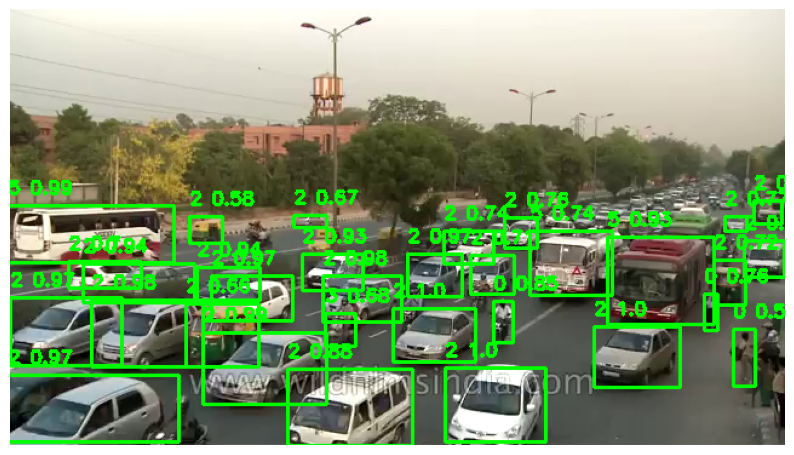

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load YOLO
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Upload video
video_file = "traffic.mp4"  # Replace with the uploaded video file name
cap = cv2.VideoCapture(video_file)

# Process the video frame by frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Resize the frame to fit the input size of the network (YOLO requires 416x416)
    blob = cv2.dnn.blobFromImage(frame, 0.00392, (416, 416), (0, 0, 0), True, crop=False)

    # Feed the blob to the network
    net.setInput(blob)
    outputs = net.forward(output_layers)

    # Initialize lists for detected objects
    class_ids = []
    confidences = []
    boxes = []
    height, width, channels = frame.shape

    # Loop through all detected objects
    for out in outputs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            # Filter out weak detections
            if confidence > 0.5:  # Adjust the confidence threshold as needed
                # Get the object's bounding box coordinates
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                # Get the top-left corner coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                # Add the detection to the lists
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Apply non-maximum suppression to eliminate redundant boxes
    indexes = cv2.dnn.NMSBoxes(boxes, confidences, score_threshold=0.5, nms_threshold=0.4)

    # Draw bounding boxes and labels
    if len(indexes) > 0:
        for i in indexes.flatten():
            x, y, w, h = boxes[i]
            label = str(class_ids[i])
            confidence = str(round(confidences[i], 2))

            # Draw the bounding box and label on the frame
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(frame, f"{label} {confidence}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Convert the BGR frame to RGB and display the image using matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    # Break on 'q' key press (since we can't use a real-time loop in Colab, this is just an example)
    break  # Only processing the first frame for now (since real-time video processing isn't possible in Colab)

# Release the video capture object
cap.release()
